In [1]:
from sparseDPD import Volterra, DataManager, Dataset, Datapath, PNTDNN_NeuralNetwork, PGJANET_NeuralNetwork


# load pretrained model
simpleDataManager = DataManager(filepath='UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

PGJANET_forward_nn = PGJANET_NeuralNetwork(nn_file_path='pre_trained_models/pgjanet_checkpoint.pt', num_memory_levels=10, model_type='PGJANETNetwork', forward_model=True)

# Train PNTDNN inverse model
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', forward_model=False)
train_losses_inv, valid_losses_inv, best_epoch_inv = PNTDNN_inverse_nn.get_best_model(num_epochs=300, training_dataset=simpleDataManager.training_dataset, validation_dataset=simpleDataManager.validation_dataset)


Using cuda device
Using cuda device
Epoch  10/300  Loss=5.5634e+00  Valid Loss=1.7660e-01  LR=1.00e-03
Epoch  20/300  Loss=1.5829e+00  Valid Loss=5.7277e-02  LR=1.00e-03
Epoch  30/300  Loss=7.6572e-01  Valid Loss=3.3879e-02  LR=1.00e-03
Epoch  40/300  Loss=5.4888e-01  Valid Loss=2.6422e-02  LR=1.00e-03
Epoch  50/300  Loss=4.7425e-01  Valid Loss=2.3088e-02  LR=1.00e-03
Epoch  60/300  Loss=4.3405e-01  Valid Loss=2.1381e-02  LR=1.00e-03
Epoch  70/300  Loss=4.1184e-01  Valid Loss=1.9974e-02  LR=1.00e-03
Epoch  80/300  Loss=4.0376e-01  Valid Loss=1.9848e-02  LR=1.00e-03
Epoch  90/300  Loss=3.9842e-01  Valid Loss=1.9623e-02  LR=1.00e-03
Epoch 100/300  Loss=3.9370e-01  Valid Loss=1.9405e-02  LR=1.00e-03
Epoch 110/300  Loss=3.8530e-01  Valid Loss=1.8981e-02  LR=1.00e-03
Epoch 120/300  Loss=2.9906e-01  Valid Loss=1.4692e-02  LR=1.00e-03
Epoch 130/300  Loss=2.6815e-01  Valid Loss=1.3368e-02  LR=1.00e-03
Epoch 140/300  Loss=2.5079e-01  Valid Loss=1.2577e-02  LR=1.00e-03
Epoch 150/300  Loss=2.4070

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


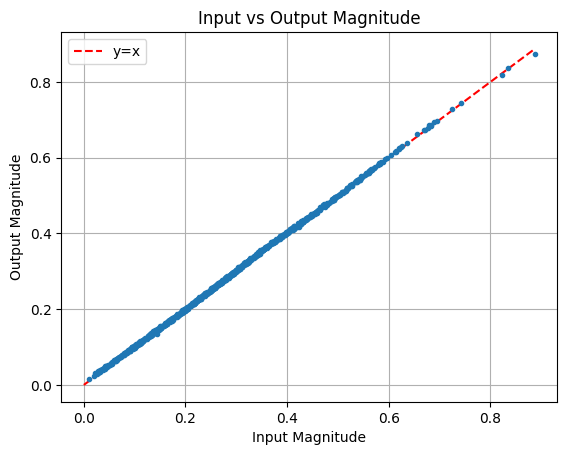

np.float64(-36.89521728333198)

In [2]:
# Create a datapath with PGJANET forward and PNTDNN inverse
datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)
# Process data through datapath
data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data[:1000])
# Plot the signals
datapath.plot_signals(data)
# Calculate NMSE
data.calculate_nmse()

Epoch  10/100  Loss=9.4615e-02  Valid Loss=7.5727e-03  LR=1.00e-03
Epoch  20/100  Loss=8.0167e-02  Valid Loss=8.5922e-03  LR=5.00e-04
Epoch  30/100  Loss=7.0683e-02  Valid Loss=6.8520e-03  LR=2.50e-04
Epoch  40/100  Loss=7.1120e-02  Valid Loss=6.6775e-03  LR=2.50e-04
Epoch  50/100  Loss=6.8110e-02  Valid Loss=6.6864e-03  LR=1.25e-04
Epoch  60/100  Loss=6.6754e-02  Valid Loss=6.3630e-03  LR=6.25e-05
Epoch  70/100  Loss=6.6804e-02  Valid Loss=6.3597e-03  LR=6.25e-05
Epoch  80/100  Loss=6.6049e-02  Valid Loss=6.3461e-03  LR=3.13e-05
Epoch  90/100  Loss=6.6048e-02  Valid Loss=6.3359e-03  LR=3.13e-05
Epoch 100/100  Loss=6.6043e-02  Valid Loss=6.3206e-03  LR=3.13e-05

Best model from epoch 100 with validation loss: 6.3206e-03
Epoch  10/100  Loss=9.4301e-02  Valid Loss=7.1549e-03  LR=1.00e-03
Epoch  20/100  Loss=9.3848e-02  Valid Loss=7.0055e-03  LR=1.00e-03
Epoch  30/100  Loss=9.2337e-02  Valid Loss=6.9773e-03  LR=1.00e-03
Epoch  40/100  Loss=9.1282e-02  Valid Loss=6.9908e-03  LR=5.00e-04
Ep

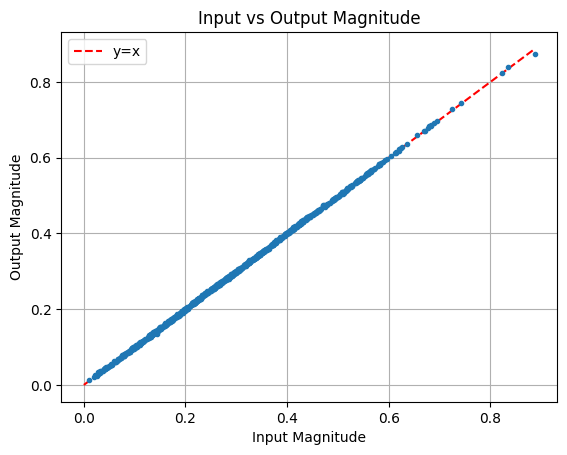

np.float64(-41.296344992341716)

In [6]:
# try using iterative indirect learning to see if you get better results
import matplotlib.pyplot as plt
import numpy as np

iterations = 6

total_trim = PNTDNN_inverse_nn.num_memory_levels + (PGJANET_forward_nn.seq_len - 1)

# Use ILA training
datapath.train_using_ila(training_dataset=simpleDataManager.training_dataset, valid_dataset=simpleDataManager.validation_dataset, iterations=iterations, retrain_epochs_per_iteration=100)

data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data[:1000])
# Plot the signals
datapath.plot_signals(data)
# Calculate NMSE
data.calculate_nmse()